# [Prototype] Process calibration results

Idea: load and check features of results from the multistage calibration process.
Test the concept of combining seasons and filtering/updating by outbreak features

In [1]:
import io
import sys
import time
from argparse import ArgumentParser
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Optional

import matplotlib as mpl
import matplotlib.pyplot as plt
import plotly
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import pandas as pd
import scipy.stats

from inframind_proteus import BaseConfig
from inframind_proteus.empirical_data import DiseaseTimeSeriesCache
from inframind_proteus.outbreak_dynamics import SimulationConfig
from inframind_proteus.outbreak_dynamics.utils import (
    parse_set_arguments_with_yaml, load_yaml_dict, year_week_to_date,
    apply_include_exclude_logic, map_parallel_or_sequential
)
from scripts.calibrate_3rd_imdc.program_config import ProgramConfig
from scripts.calibrate_3rd_imdc.calibration_stage_1 import (
    run_calibration_stage_1, Stage1Outputs
)
from scripts.calibrate_3rd_imdc.calibration_stage_2 import (
    run_calibration_stage_2, Stage2Outputs
)
from scripts.calibrate_3rd_imdc.calibration_stage_3 import (
    run_calibration_stage_3, Stage3Outputs
)

In [2]:

year, location_id = 2022, "SP"
# year, location_id = 2022, "DF"

main_out_dir = Path("../../outputs/validation_round_calibration/")
disease_cases_dir = Path("../../data/disease/dengue_cases_uf_weekly")

# ================
out_dir = main_out_dir / f"{location_id}_{year}"

sim_config_dict = load_yaml_dict(out_dir / "stage3_sim_config.yaml", safe=False)

mean_cases_df = pd.read_csv(
    out_dir / "stage3_mean_cases.csv.gz",
    index_col=0,
)
mean_cases_df.columns = pd.to_datetime(mean_cases_df.columns)

posterior_samples_df = pd.read_csv(
    out_dir / "stage3_posterior_samples.csv.gz",
    index_col=0,
)

observations_sr = DiseaseTimeSeriesCache(disease_cases_dir).get_location(location_id)


mean_cases_df
posterior_samples_df



,rt_logist_r_high,rt_logist_start,notif_nb_overdispersion,posterior_weight
i_simulation,,,,
222906,1.849048,27.563412,40.222076,0.001038
155106,1.846123,27.625619,40.008824,0.001038
11473,1.835054,27.884455,37.709650,0.001038
40262,1.827676,28.250819,0.454930,0.001123
145988,1.829083,28.021535,0.455972,0.001123
...,...,...,...,...
164126,1.847889,27.531651,16.689172,0.962963
220004,1.849088,28.137347,17.219055,0.962963
86153,1.849250,28.208280,17.608005,0.962963


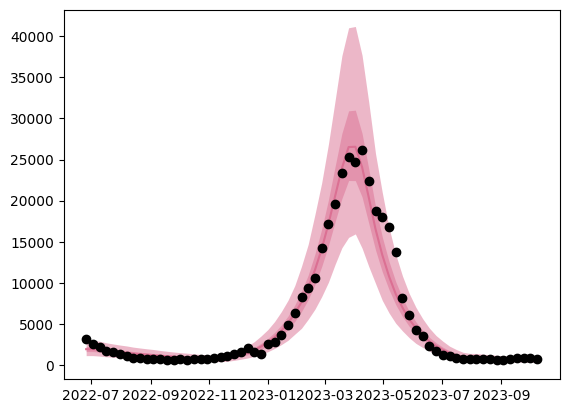

In [3]:
# Sample trajectories from the model case beams
# =============================================
sim_config_dict

d = sim_config_dict["observation_model"]
if d["model"] != "negative_binomial":
    raise NotImplementedError("Only negative binomial observation model is supported.")

rng = np.random.default_rng(seed=42)

# --- Re-sample from the posterior to choose trajectories to sample from
num_trajectories = 1000
re_sample_params: pd.DataFrame = posterior_samples_df.sample(
    n=num_trajectories,
    replace=True,
    weights=posterior_samples_df["posterior_weight"],
    random_state=rng,
)

re_sample_mean_cases = mean_cases_df.reindex(re_sample_params.index)

# After identifying original simulations, reset the indexes to sequential
for obj in [re_sample_params, re_sample_mean_cases]:
    obj.reset_index(drop=True, inplace=True)
    obj.index.name = "i_sample"

# --- Reshape to 2D arrays and sample everything at once
# Standard shape: (i_sample, i_time)
_expectancy = re_sample_mean_cases.values
_overdisp = re_sample_params["notif_nb_overdispersion"].to_numpy()[:, np.newaxis]
p = _overdisp / (_overdisp + _expectancy)

cases_vec: np.ndarray = rng.negative_binomial(
    n=_overdisp, p=p, size=_expectancy.shape
)
cases_df = pd.DataFrame(
    cases_vec,
    index=re_sample_params.index,
    columns=re_sample_mean_cases.columns
)

cases_df

# --- Visualize sampled trajectories
fig, ax = plt.subplots()

with mpl.rc_context(
        {
            "patch.linewidth": 0,
        }
):
    # === Model trajectories
    ax.fill_between(
        cases_df.columns,
        cases_df.quantile(0.025), cases_df.quantile(0.975),
        color="palevioletred", alpha=0.5, label="95% CI"
    )
    ax.fill_between(
        cases_df.columns,
        cases_df.quantile(0.25), cases_df.quantile(0.75),
        color="palevioletred", alpha=0.5, label="50% CI"
    )

    ax.plot(cases_df.median(), label="Median", color="palevioletred")

    # === Observations
    sr = observations_sr[cases_df.columns]
    ax.plot(sr, label="Observations", color="black", marker="o", linestyle="")

    fig

## Outbreak features from trajectories
- Feats
    - case_attack_rate
    - peak_date
    - peak_amplitude
- Consider only the IMDC window (currenrlt same as calibration window)

,case_attack_rate,peak_week,peak_amplitude
i_sample,,,
0,345328,22.0,32321
1,307632,25.0,36788
2,338203,25.0,41820
3,328358,24.0,29708
4,346355,28.0,30461
...,...,...,...
9995,350382,25.0,32525
9996,327634,25.0,36278
9997,340375,27.0,28662


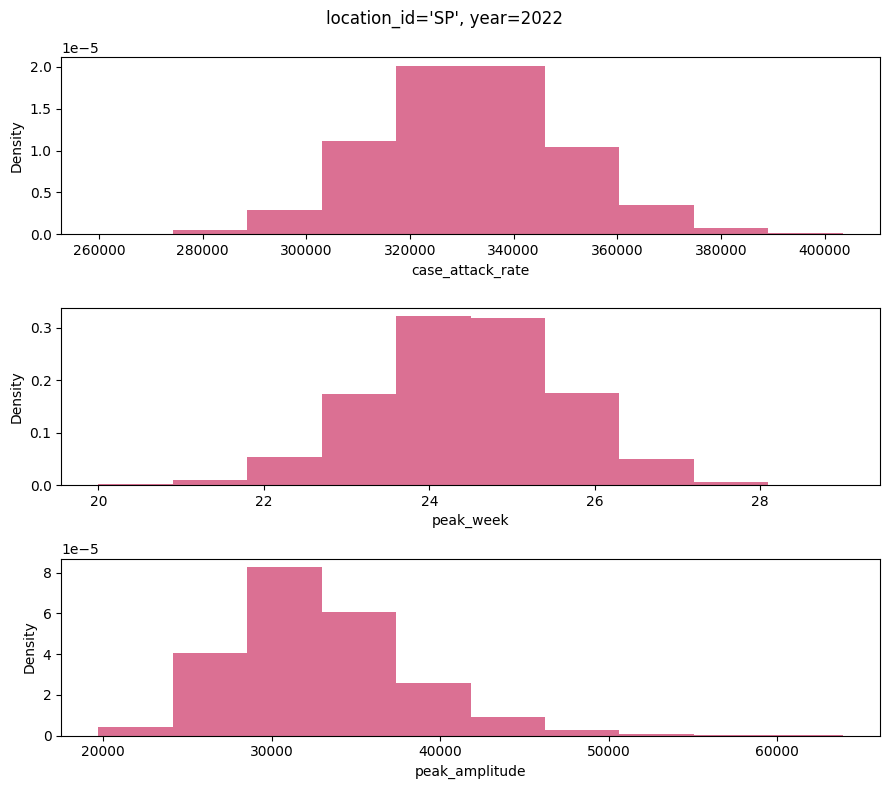

In [7]:
# --- Crop calculation window
d = sim_config_dict
window_start = pd.Timestamp(d["temporal"]["calibration_start"])
window_end = pd.Timestamp(d["temporal"]["calibration_end"])
df = cases_df.loc[:, window_start:window_end]
obs = observations_sr.loc[window_start:window_end]  # If observations

# Etc params
date_zero = pd.Timestamp(d["temporal"]["zero_date"])

# ====
features = pd.DataFrame(index=df.index)

features["case_attack_rate"] = df.sum(axis=1)
features["peak_week"] = (df.idxmax(axis=1) - date_zero).dt.days / 7
features["peak_amplitude"] = df.max(axis=1)


# ================

with plt.rc_context({

}):
    feat_names = features.columns.to_list()
    fig, axes = plt.subplots(
        nrows=len(feat_names),
        ncols=1,
        figsize=(3*len(feat_names), 8)
    )

    for i_feat, feat_name in enumerate(feat_names):
        ax: plt.Axes = axes[i_feat]
        feat_vals = features[feat_name]

        # --- Histogram
        ax.hist(
            feat_vals,
            density=True,
            color="palevioletred",
        )

        ax.set_xlabel(feat_name)
        ax.set_ylabel("Density")

    fig.suptitle(f"{location_id=}, {year=}")
    fig.tight_layout()

    fig.savefig(
        out_dir / "outbreak_feature_estimates.pdf",
    )

features




In [18]:
# Print config dict
import yaml

s = io.StringIO()
yaml.dump(d, s)

print(s.getvalue())

gt_max: 49
initial_infections: !!python/object:inframind_proteus.outbreak_dynamics.initial_infections.InitialInfectionsConfig
  method: ones
  num_steps: 7
  params: {}
location:
  location_id: SP
  location_id_variable: uf
  population_size: 45736978
mode: calibration
num_simulations: 262144
num_time_steps: 68
observation_model:
  model: negative_binomial
  params:
    notif_nb_overdispersion: 150.0
    notif_relative_scale: 5.09825745194647
    notif_scaling_factor: 250.0
  reference_population_size: 100000
output:
  keep_rt_trajectories: true
  main_dir: outputs/prototype_run_dynamic_model
rng_seed: 123
sampling: !!python/object:inframind_proteus.outbreak_dynamics.sampling.SamplingConfig
  method: sobol
  observation_params:
    notif_nb_overdispersion: 150.0
    notif_relative_scale: 5.09825745194647
    notif_scaling_factor: 250.0
  param_priors: {}
  param_ranges: {}
  param_scales:
    notif_nb_overdispersion: inverse
  rng_seed: 123
  rt_params:
    rt_logist_dt_center: 129.213

In [21]:
d["sampling"].rt_params

{'rt_logist_dt_center': 129.21377019956708,
 'rt_logist_dt_end': 118.61710039898753,
 'rt_logist_r_high': 2.0,
 'rt_logist_r_low': 0.5,
 'rt_logist_r_off': 0.8503649977967143,
 'rt_logist_start': 50.0,
 'rt_logist_w_center': 7.094858436379582,
 'rt_logist_w_env': 2.5}